7 zbiorów:

1. Zbiór krótkich nagrań typowych dla testowania metod
2. Zbiór krótkich nagrań bez overlapingu
3. Zbiór dialogów z małą liczbą overlapingu
4. Zbiór dialogów z dużą liczbą overlapingu
5. Zbiór długich dialogów (3-5min) z małą liczbą overlapingów
6. Zbiór długich dialogów z dużą liczbą overlapingów
7. Zbiór długich dialogów bez overlapingu

Forma danych:

- Nagranie złączone
- csv wiersz na fragment składowy, kolumny: id_dialogu, id_nagrania, start, end, text, speaker

Forma testów:

- podział danych na segmenty z overlapingiem i bez
- traktowanie fragmentów bez overlapingu jako fragment z drugim mówcą o zerowej fali
- wyliczanie standardowych metryk osobno dla fragmentów z overlapingiem i bez
- wyliczanie metryk jednocześnie dla obu mówców przez złączenie ich nagrań pionowo

Moja metryka:

- operuje na spektrogramie
- wyznaczenie spec_max = max(spec1, spec2)
- obliczenie metryki jako (sum(spec1) + sum(spec2)) / sum(spec_max) - 1
- do rozważenia dodanie dylatacji dla uwzględnienia mikroprzesunięć sygnału

In [2]:
from src.prepare_datasets import *

### Nagrania jednego mówcy

In [32]:
prepare_dialogue_dataset(1000, 'data/test/single_speaker', 'data/metadata_test.csv', min_speakers=1, max_speakers=1,
                         min_fragments_per_speaker=1, max_fragments_per_speaker=1, min_speaker_time=0,
                         min_speaker_reception_time=0, min_fragment_duration=2, max_fragment_duration=10, save_format='frame')

100%|██████████| 1000/1000 [00:07<00:00, 140.00it/s]

Overlap time: 0.0 %
Średnia długość nagrań: 4.120948187499996


### Tradycyjne nakładanie

In [3]:
prepare_dialogue_dataset(1000, 'data/test/2_speakers', 'data/metadata_test.csv', min_speakers=2, max_speakers=2, overlap_prob=1,
                         min_fragments_per_speaker=1, max_fragments_per_speaker=1, min_speaker_time=0, min_overlap=4, max_overlap=8,
                         min_speaker_reception_time=0, min_fragment_duration=5, max_fragment_duration=10, save_format='frame')

100%|██████████| 1000/1000 [00:16<00:00, 58.98it/s]

Overlap time: 38.475691461703384 %
Średnia długość nagrań: 9.8712421875


### Dialogi z małą ilością overlapingu

In [2]:
prepare_dialogue_dataset(1000, 'data/test/low_overlaping', 'data/metadata_test.csv', overlap_prob=0.15, save_format='frame')

100%|██████████| 1000/1000 [00:31<00:00, 32.05it/s]

Overlap time: 4.600637348909681 %
Średnia długość nagrań: 47.463052875


### Dialogi z dużą ilością overlapingu

In [3]:
prepare_dialogue_dataset(1000, 'data/test/high_overlaping', 'data/metadata_test.csv', overlap_prob=0.6, save_format='frame')

100%|██████████| 1000/1000 [00:29<00:00, 33.50it/s]

Overlap time: 16.745470785553902 %
Średnia długość nagrań: 39.8043915


### Długie dialogi z małą ilością overlapingu

In [4]:
prepare_dialogue_dataset(1000, 'data/test/long_low_overlaping', 'data/metadata_test.csv', overlap_prob=0.15,
                         min_speakers=3, max_speakers=5, min_speaker_time=30, min_fragments_per_speaker=5, max_fragments_per_speaker=10,
                         min_speaker_reception_time=60, save_format='frame')

100%|██████████| 1000/1000 [02:19<00:00,  7.18it/s]


Overlap time: 4.698421129887384 %
Średnia długość nagrań: 174.41543975


In [5]:
prepare_dialogue_dataset(1000, 'data/test/long_high_overlaping', 'data/metadata_test.csv', overlap_prob=0.6,
                         min_speakers=3, max_speakers=5, min_speaker_time=30, min_fragments_per_speaker=5, max_fragments_per_speaker=10,
                         min_speaker_reception_time=60, save_format='frame')

100%|██████████| 1000/1000 [02:07<00:00,  7.82it/s]

Overlap time: 17.900428246395446 %
Średnia długość nagrań: 150.000095


# Metody separacji

In [9]:
import torch
import numpy as np
from scipy.io.wavfile import write
from tqdm import tqdm
import time
import os
import pandas as pd

In [3]:
from src.metrics import *

In [4]:
from pyannote.audio import Pipeline
from dotenv import load_dotenv
import os

load_dotenv()
API_KEY = os.getenv("API_KEY")

overlap_detection = Pipeline.from_pretrained("pyannote/overlapped-speech-detection", use_auth_token=API_KEY)
overlap_detection.instantiate({
    'onset': 0.2,
    'offset': 0.2,
    'min_duration_on': 0.5,
    'min_duration_off': 0.5
})

c:\Studia\.conda\Lib\inspect.py:988: UserWarning: Module 'speechbrain.pretrained' was deprecated, redirecting to 'speechbrain.inference'. Please update your script. This is a change from SpeechBrain 1.0. See: https://github.com/speechbrain/speechbrain/releases/tag/v1.0.0
  if ismodule(module) and hasattr(module, '__file__'):
c:\Studia\.conda\Lib\site-packages\pytorch_lightning\utilities\migration\migration.py:208: You have multiple `ModelCheckpoint` callback states in this checkpoint, but we found state keys that would end up colliding with each other after an upgrade, which means we can't differentiate which of your checkpoint callbacks needs which states. At least one of your `ModelCheckpoint` callbacks will not be able to reload the state.
Lightning automatically upgraded your loaded checkpoint from v1.1.3 to v2.4.0. To apply the upgrade to your files permanently, run `python -m pytorch_lightning.utilities.upgrade_checkpoint C:\Users\wikto\.cache\torch\pyannote\models--pyannote--seg

Model was trained with pyannote.audio 0.0.1, yours is 3.3.2. Bad things might happen unless you revert pyannote.audio to 0.x.
Model was trained with torch 1.7.1, yours is 2.5.1+cu124. Bad things might happen unless you revert torch to 1.x.


In [1]:
def match_size(ref_wav, gen_wav):
    if len(ref_wav) > len(gen_wav):
        gen_wav = np.pad(gen_wav, (0, len(ref_wav) - len(gen_wav)), 'constant')
    elif len(ref_wav) < len(gen_wav):
        gen_wav = gen_wav[:len(ref_wav)]
    return gen_wav

def css_split(mix, model):
    spk1, spk2 = model(mix)
    return match_size(mix, spk1), match_size(mix, spk2)

OVERLAP_MARGIN = 0.5

# def connect_fragments(fragments):
#     if not fragments:
#         return None, None
#     fragments.sort(key=lambda x: x[0])
#     start1, end1, canal1 = fragments[0]
#     if len(fragments) == 1:
#         return canal1, np.zeros_like(canal1)
#     start2, end2, canal2 = fragments[1]
#     for start, end, wav in fragments[2:]:
#         if start1 <= start2:
#             canal1 = np.concatenate([canal1, np.zeros(start - start1), wav])
#             start1 = start
#         else:
#             canal2 = np.concatenate([canal2, np.zeros(start - start2), wav])
#             start2 = start
#     if start1 < start2:
#         canal1 = np.concatenate([canal1, np.zeros(start2 - start1)])
#     elif start2 < start1:
#         canal2 = np.concatenate([canal2, np.zeros(start1 - start2)])
#     return canal1, canal2

def connect_fragments(fragments, length):
    canal1 = np.zeros(length)
    canal2 = np.zeros(length)

    if not fragments:
        return canal1, canal2
    
    fragments.sort(key=lambda x: x[0])

    start1, end1, wav = fragments[0]
    canal1[start1:end1] = wav

    if len(fragments) == 1:
        return canal1, canal2
    
    start2, end2, wav = fragments[1]
    canal2[start2:end2] = wav

    for start, end, wav in fragments[2:]:
        if end1 <= end2:
            canal1[start:end] = wav
            end1 = end
        else:
            canal2[start:end] = wav
            end2 = end
            
    return canal1, canal2


def odis_split(mix, model):
    overlaps = overlap_detection({"waveform": torch.Tensor(mix).unsqueeze(0), "sample_rate": 16000})
    if not overlaps:
        return mix, np.zeros_like(mix)
    file_fragments = []
    current_segment = None
    current_start = 0
    margin = int(OVERLAP_MARGIN * 16000)
    for segment in overlaps.itersegments():
        start = int(segment.start * 16000)
        end = min(int(segment.end * 16000), len(mix))
        # print(f"Processing segment: {start} to {end}, length: {end - start}")
        extended_start = max(0, start - margin)
        extended_end = min(mix.shape[-1], end + margin)

        start2 = min(start, margin)
        end2 = start2 + end - start

        separated = list(model(mix[extended_start : extended_end]))
        best_before_score = -1
        best_after_score = -1
        best_before_idx = -1
        best_after_idx = -1

        for j, separated_voice in enumerate(separated):
            before_score = np.mean(separated_voice[:start2]**2)
            after_score = np.mean(separated_voice[end2:]**2)
            separated[j] = separated[j][start2:end2]
            if before_score > best_before_score:
                best_before_score = before_score
                best_before_idx = j
            if after_score > best_after_score:
                best_after_score = after_score
                best_after_idx = j
                
        if current_segment is None:
            current_segment = np.concatenate([mix[:start], separated[best_before_idx]])
        else:
            current_segment = np.concatenate([current_segment, mix[prev_end:start], separated[best_before_idx]])

        if best_before_idx != best_after_idx:
            file_fragments.append((current_start, current_start + len(current_segment), current_segment))
            current_start = start
            current_segment = separated[best_after_idx]

        for j, separated_voice in enumerate(separated):
            if j != best_before_idx and j != best_after_idx:
                file_fragments.append((start, start + len(separated_voice), separated_voice))

        prev_end = end
            
    current_segment = np.concatenate([current_segment, mix[prev_end:]])
    file_fragments.append((current_start, current_start + len(current_segment), current_segment))

    # for start, end, wav in file_fragments:
    #     print(start, end, len(wav))
    #     if end - start != len(wav):
    #         print(f"Warning: Fragment length mismatch: {end - start} != {len(wav)}")
    #     if start < 0:
    #         print(f"Warning: Fragment start is negative: {start}")
    #     if end > len(mix):
    #         print(f"Warning: Fragment end exceeds mix length: {end} > {len(mix)}")

    canal1, canal2 = connect_fragments(file_fragments, len(mix)) 

    return match_size(mix, canal1), match_size(mix, canal2)

In [5]:
def odis_split_with_knowledge(mix, model, overlaps):
    if not overlaps:
        return mix, np.zeros_like(mix)
    file_fragments = []
    current_segment = None
    current_start = 0
    margin = int(OVERLAP_MARGIN * 16000)
    for start, end in overlaps:
        extended_start = max(0, start - margin)
        extended_end = min(mix.shape[-1], end + margin)

        start2 = min(start, margin)
        end2 = start2 + end - start

        separated = list(model(mix[extended_start : extended_end]))
        best_before_score = -1
        best_after_score = -1
        best_before_idx = -1
        best_after_idx = -1

        for j, separated_voice in enumerate(separated):
            before_score = np.mean(separated_voice[:start2]**2)
            after_score = np.mean(separated_voice[end2:]**2)
            separated[j] = separated[j][start2:end2]
            if before_score > best_before_score:
                best_before_score = before_score
                best_before_idx = j
            if after_score > best_after_score:
                best_after_score = after_score
                best_after_idx = j
                
        if current_segment is None:
            current_segment = np.concatenate([mix[:start], separated[best_before_idx]])
        else:
            current_segment = np.concatenate([current_segment, mix[prev_end:start], separated[best_before_idx]])

        if best_before_idx != best_after_idx:
            file_fragments.append((current_start, current_start + len(current_segment), current_segment))
            current_start = start
            current_segment = separated[best_after_idx]

        for j, separated_voice in enumerate(separated):
            if j != best_before_idx and j != best_after_idx:
                file_fragments.append((start, start + len(separated_voice), separated_voice))

        prev_end = end
            
    current_segment = np.concatenate([current_segment, mix[end:]])

    file_fragments.append((current_start, current_start + len(current_segment), current_segment))
    canal1, canal2 = connect_fragments(file_fragments, len(mix)) 

    return match_size(mix, canal1), match_size(mix, canal2)

# Mczytanie modeli

In [6]:
import sys
sys.path.append('src/mossformer2')
from src.mossformer2.mossformer2 import MossFormer2_adapted
mossformer_16 = MossFormer2_adapted('src/mossformer2/checkpoints')

def split_with_mossformer2(mix):
    spk1, spk2 = mossformer_16(np.array([mix]))
    return spk1, spk2

def css_mossformer2(mix):
    return css_split(mix, split_with_mossformer2)

def odis_mossformer2(mix):
    return odis_split(mix, split_with_mossformer2)

c:\Studia\Master_Thesis\src\mossformer2\mossformer2_utils.py:10: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(


In [ ]:
from src.fastgeco.fastgeco import GeCo
import torch
fastgeco = GeCo('src/fastgeco/Fast-GeCo/checkpoints')
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

def split_with_fastgeco(mix):
    mix = librosa.resample(mix, 16000, 8000)
    mix = torch.tensor(mix).to(device)
    spk1, spk2 = fastgeco(mix)
    return librosa.resample(np.array(spk1.cpu()), 8000, 16000), librosa.resample(np.array(spk2.cpu()), 8000, 16000)

def css_fastgeco(mix):
    return css_split(mix, split_with_fastgeco)

def odis_fastgeco(mix):
    return odis_split(mix, split_with_fastgeco)

c:\Studia\Master_Thesis\src\fastgeco\fastgeco.py:65: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  encoder_weights = torch.load(os.path.join(ckpt_path, 'encoder.ckpt'))
c:\S

In [ ]:
from src.sepreformer.sepreformer import SepReformer
import torch
sepreformer = SepReformer()
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

def split_with_sepreformer(mix):
    mix = librosa.resample(mix, 16000, 8000)
    mix = torch.tensor(mix).to(device)
    spk1, spk2 = sepreformer(mix)
    return librosa.resample(np.array(spk1.cpu()), 8000, 16000), librosa.resample(np.array(spk2.cpu()), 8000, 16000)

def css_sepreformer(mix):
    return css_split(mix, split_with_sepreformer)

def odis_sepreformer(mix):
    return odis_split(mix, split_with_sepreformer)

In [94]:
import sys
sys.path.append('src')

from src.espnet.espnet2.bin.enh_inference import SeparateSpeech

locoformer = SeparateSpeech(
    train_config='src/espnet/egs2/wsj0_2mix/enh1/exp/enh_train_enh_tflocoformer_pretrained/config.yaml',
    model_file='src/espnet/egs2/wsj0_2mix/enh1/exp/enh_train_enh_tflocoformer_pretrained/valid.loss.ave_5best.pth',
    normalize_output_wav=True,
    device="cuda:0",
)

def split_with_locoformer(input):
    input = librosa.resample(input, orig_sr=16000, target_sr=8000)
    input /= input.std(axis=-1)
    spk1, spk2 = locoformer(input[None], 8000)
    # return np.array(spk1[0]), np.array(spk2[0])
    return librosa.resample(np.array(spk1[0]), orig_sr=8000, target_sr=16000), librosa.resample(np.array(spk2[0]), orig_sr=8000, target_sr=16000)

def css_locoformer(mix):
    return css_split(mix, split_with_locoformer)

def odis_locoformer(mix):
    return odis_split(mix, split_with_locoformer)

c:\Studia\Master_Thesis\src\espnet\espnet2\enh\loss\criterions\time_domain.py:446: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  @torch.cuda.amp.autocast(enabled=False)
c:\Studia\Master_Thesis\src\espnet\espnet2\enh\layers\tcn.py:458: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  @torch.cuda.amp.autocast(enabled=False)
c:\Studia\Master_Thesis\src\espnet\espnet2\enh\layers\tcn.py:499: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  @torch.cuda.amp.autocast(enabled=False)
c:\Studia\Master_Thesis\src\espnet\espnet2\enh\layers\uses.py:392: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  @torch.cuda.amp.autocast(enabled=False)
c:\Studia\Master_Thesis\src\espnet\espnet2\enh\layers\uses

# Separacja

In [7]:
def separate_and_save(method, method_name, datasets, sr=16000):
    for dataset, m, n in datasets:
        os.makedirs(f'data/test/output/{method_name}/{dataset}', exist_ok=True)
        log_path = f'data/test/output/{method_name}/{dataset}/timing.csv'
        file_exists = os.path.exists(log_path)
        if not file_exists:
            with open(log_path, 'a') as log_file:
                log_file.write('sample_id,process_time,real_time\n')
        for i in tqdm(range(m, n), desc=dataset):
            wav = librosa.load(f"data/test/{dataset}/{i}.wav", sr=sr)[0]

            start = time.perf_counter()
            spk1, spk2 = method(wav)
            end = time.perf_counter()

            process_time = end - start
            real_time = len(wav) / sr
            
            write(f'data/test/output/{method_name}/{dataset}/{i}_1.wav', sr, spk1)
            write(f'data/test/output/{method_name}/{dataset}/{i}_2.wav', sr, spk2)
            
            with open(log_path, 'a') as log_file:
                log_file.write(f"{i},{process_time:.6f},{real_time:.6f}\n")

In [ ]:
separate_and_save(css_mossformer2, 'css_mossformer2', [
    ('single_speaker', 0, 100),
    ('2_speakers', 0, 500),
    ('low_overlaping', 0, 500),
    ('high_overlaping', 0, 500),
    ('long_low_overlaping', 0, 200),
    ('long_high_overlaping', 0, 200)
])

In [75]:
separate_and_save(odis_mossformer2, 'odis_mossformer2', [
    # ('single_speaker', 0, 100),
    # ('2_speakers', 0, 500),
    ('low_overlaping', 0, 500),
    ('high_overlaping', 0, 500),
    ('long_low_overlaping', 0, 200),
    ('long_high_overlaping', 0, 200)
])

long_high_overlaping: 100%|██████████| 200/200 [34:22<00:00, 10.31s/it]


In [ ]:
separate_and_save(css_locoformer, 'css_locoformer', [
    ('single_speaker', 0, 100),
    ('2_speakers', 0, 500),
    ('low_overlaping', 0, 500),
    ('high_overlaping', 0, 500)
])

In [99]:
separate_and_save(odis_locoformer, 'odis_locoformer', [
    ('single_speaker', 0, 100),
    ('2_speakers', 0, 500),
    ('low_overlaping', 0, 500),
    ('high_overlaping', 0, 500)
])

single_speaker:  67%|██████▋   | 67/100 [00:02<00:01, 29.02it/s]c:\Studia\Master_Thesis\src\espnet\espnet2\enh\separator\tflocoformer_separator.py:165: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=False):
c:\Studia\.conda\Lib\contextlib.py:105: FutureWarning: `torch.backends.cuda.sdp_kernel()` is deprecated. In the future, this context manager will be removed. Please see `torch.nn.attention.sdpa_kernel()` for the new context manager, with updated signature.
  self.gen = func(*args, **kwds)
c:\Studia\Master_Thesis\src\espnet\espnet2\enh\separator\tflocoformer_separator.py:172: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=False):
high_overlaping:  48%|████▊     | 242/500 [04:00<05:48,  1.35s/it]c:\Studia\.conda\Lib\site-packages\numpy\core\fromnumeric.py:350

In [10]:
def separate_and_save_with_knowledge(method_name, datasets, sr=16000):
    for dataset, m, n in datasets:
        overlaps = pd.read_csv(f'data/test/{dataset}/overlaps.csv')
        os.makedirs(f'data/test/output/{method_name}/{dataset}', exist_ok=True)
        log_path = f'data/test/output/{method_name}/{dataset}/timing.csv'
        file_exists = os.path.exists(log_path)
        if not file_exists:
            with open(log_path, 'a') as log_file:
                log_file.write('sample_id,process_time,real_time\n')
        for i in tqdm(range(m, n), desc=dataset):
            wav = librosa.load(f"data/test/{dataset}/{i}.wav", sr=sr)[0]

            spk1, spk2 = odis_split_with_knowledge(wav, css_mossformer2, [(row['start'], row['end']) for _, row in overlaps[overlaps['sample_id'] == i].iterrows()])
            
            write(f'data/test/output/{method_name}/{dataset}/{i}_1.wav', sr, spk1)
            write(f'data/test/output/{method_name}/{dataset}/{i}_2.wav', sr, spk2)

separate_and_save_with_knowledge('odis_mossformer2_with_knowledge', [
    ('low_overlaping', 0, 500),
    ('high_overlaping', 0, 500)
])

high_overlaping: 100%|██████████| 500/500 [18:20<00:00,  2.20s/it]


# Ewaluacja

In [13]:
from collections import defaultdict, deque
import numpy as np
import librosa
import pandas as pd
import json
from tqdm import tqdm
from src.metrics import get_SI_SDR, get_STOI, get_SI_MSS, get_SI_MES

import numpy as np


def get_PESQ(reference, estimated, sr, window_size=60):
    
    from pesq import pesq
    window_size *= sr
    if len(reference) <= window_size:
        return pesq(sr, reference, estimated, 'wb')
    score = 0
    for i in range(0, len(reference), window_size):
        end = min(len(reference), i+window_size)
        start = end - max(4000, end - i)
        ref = reference[start:end]
        est = estimated[start:end]
        if np.all(est == 0):
            score += 4.5 * np.sum(ref[i - start:] == 0)
        else:
            try:
                score += pesq(sr, ref, est, 'wb') * (end - i)
            except Exception as e:
                score += 1.0 * (end - i)
    return score / len(reference)


def group_overlapping_segments(segments: list[tuple[float, float, str, np.ndarray]]) -> list[list[tuple[float, float, str, np.ndarray]]]:
    """
    Grupuje fragmenty na listy nakładających się segmentów.
    """
    def overlaps(seg1, seg2):
        start1, end1, _, _ = seg1
        start2, end2, _, _ = seg2
        return max(start1, start2) < min(end1, end2)

    # segments = sorted(segments, key=lambda x: x[0])
    adjacency = defaultdict(list)
    for i in range(len(segments)):
        for j in range(i + 1, len(segments)):
            if overlaps(segments[i], segments[j]):
                adjacency[i].append(j)
                adjacency[j].append(i)

    visited = [False] * len(segments)
    groups = []

    for i in range(len(segments)):
        if not visited[i]:
            group = []
            queue = deque([i])
            visited[i] = True
            while queue:
                node = queue.popleft()
                group.append(segments[node])
                for neighbor in adjacency[node]:
                    if not visited[neighbor]:
                        visited[neighbor] = True
                        queue.append(neighbor)
            groups.append(group)

    return groups


def get_group_wav(group: list[tuple[float, float, str, np.ndarray]]) -> tuple[list, list]:
    def overlaps(seg1, seg2):
        start1, end1, _, _ = seg1
        start2, end2, _, _ = seg2
        return max(start1, start2) < min(end1, end2)

    adjacency = defaultdict(list)
    for i in range(len(group)):
        for j in range(i + 1, len(group)):
            if overlaps(group[i], group[j]):
                adjacency[i].append(j)
                adjacency[j].append(i)

    color = {}
    for i in range(len(group)):
        if i not in color:
            queue = deque([(i, 0)])
            while queue:
                node, c = queue.popleft()
                if node in color:
                    if color[node] != c:
                        raise ValueError("Graph is not bipartite (should not happen in your case)")
                    continue
                color[node] = c
                for neighbor in adjacency[node]:
                    queue.append((neighbor, 1 - c))

    group0 = [group[i] for i in range(len(group)) if color[i] == 0]
    group1 = [group[i] for i in range(len(group)) if color[i] == 1]
    return group0, group1


def split_and_annotate_fragments_grouped(segments: list[tuple[float, float, str, np.ndarray]]) -> list[list[tuple[float, float, np.ndarray, bool, int]]]:
    """
    Dzieli fragmenty na mniejsze po wszystkich punktach startu/końca,
    grupuje na nachodzące na siebie, oznacza overlap i kanał.
    Zwraca listę list: dla każdej grupy lista (start, end, wav, is_overlap, channel)
    """
    # Grupuj na nachodzące na siebie
    groups = group_overlapping_segments(segments)

    all_grouped_annotated = []
    for group in groups:
        # Zbierz wszystkie punkty podziału w tej grupie
        split_points = set()
        for start, end, _, _ in group:
            split_points.add(start)
            split_points.add(end)
        split_points = sorted(split_points)

        # Podziel fragmenty na mniejsze
        small_frags = []
        for start, end, file, wav in group:
            frag_start = start
            for sp in split_points:
                if sp <= frag_start or sp >= end:
                    continue
                small_frags.append((frag_start, sp, file, wav[frag_start - start:sp - start]))
                frag_start = sp
            small_frags.append((frag_start, end, file, wav[frag_start - start:]))

        # Przypisz kanały w grupie
        g0, g1 = get_group_wav(group)
        file_to_channel = {}
        for seg in g0:
            file_to_channel[seg[2]] = 0
        for seg in g1:
            file_to_channel[seg[2]] = 1

        # Oznacz overlap dla każdego małego fragmentu
        annotated = []
        for frag in small_frags:
            s, e, file, wav = frag
            # Czy w tej grupie jest więcej niż jeden fragment aktywny w tym czasie?
            active = sum((max(s, seg[0]) < min(e, seg[1])) for seg in group)
            overlap = active > 1
            channel = file_to_channel[file]
            annotated.append((s, e, wav, overlap, channel))
        all_grouped_annotated.append(annotated)
    return all_grouped_annotated


def evaluate(ref_fragments: list[tuple[float, float, np.ndarray]], gen1: np.ndarray, gen2: np.ndarray, n):
    ref_fragments = split_and_annotate_fragments_grouped(ref_fragments)

    ref_no_overlap = np.zeros(0)
    ref_overlap = np.zeros(0)
    gen_no_overlap = np.zeros(0)
    gen_overlap = np.zeros(0)

    correct_match = 0
    all_match = 0
    for group in ref_fragments:
        match_1_1 = 0
        match_1_2 = 0
        group.sort(key=lambda x: x[0])
        prev_wav = None
        for start, end, wav, is_overlap, channel in group:
            gen_fragment1 = gen1[start:end]
            gen_fragment2 = gen2[start:end]
            if is_overlap:
                if prev_wav is None:
                    prev_wav = wav
                else:
                    if channel == 0:
                        wav1 = wav
                        wav2 = prev_wav
                    else:
                        wav1 = prev_wav
                        wav2 = wav
                    prev_wav = None
                    ref_overlap = np.concatenate([ref_overlap, wav1, wav2])
                    sdr_1_1 = get_SI_SDR(np.concatenate([wav1, wav2]), np.concatenate([gen_fragment1, gen_fragment2]))
                    sdr_1_2 = get_SI_SDR(np.concatenate([wav1, wav2]), np.concatenate([gen_fragment2, gen_fragment1]))
                    if sdr_1_1 > sdr_1_2:
                        gen_overlap = np.concatenate([gen_overlap, gen_fragment1, gen_fragment2])
                        match_1_1 += 1
                    else:
                        gen_overlap = np.concatenate([gen_overlap, gen_fragment2, gen_fragment1])
                        match_1_2 += 1
            else:
                wav2 = np.zeros_like(wav)
                ref_no_overlap = np.concatenate([ref_no_overlap, wav, wav2])
                sdr_1_1 = get_SI_SDR(np.concatenate([wav, wav2]), np.concatenate([gen_fragment1, gen_fragment2]))
                sdr_1_2 = get_SI_SDR(np.concatenate([wav, wav2]), np.concatenate([gen_fragment2, gen_fragment1]))
                if sdr_1_1 > sdr_1_2:
                    gen_no_overlap = np.concatenate([gen_no_overlap, gen_fragment1, gen_fragment2])
                    match_1_1 += 1
                else:
                    gen_no_overlap = np.concatenate([gen_no_overlap, gen_fragment2, gen_fragment1])
                    match_1_2 += 1
        if len(group) == 1:
            continue
        correct_match += max(match_1_1, match_1_2)
        all_match += match_1_1 + match_1_2

    # write(f'dupa/{n}_ref_no_overlap.wav', 16000, ref_no_overlap)
    # write(f'dupa/{n}_ref_overlap.wav', 16000, ref_overlap)
    # write(f'dupa/{n}_gen_no_overlap.wav', 16000, gen_no_overlap)
    # write(f'dupa/{n}_gen_overlap.wav', 16000, gen_overlap)

    # if len(ref_no_overlap) + len(ref_overlap) != 2 * len(gen1):
    #     print('Mateusz pieprzy Izę')
    #     print(f"ref_no_overlap: {len(ref_no_overlap)}, ref_overlap: {len(ref_overlap)}, gen_no_overlap: {len(gen_no_overlap)}, gen_overlap: {len(gen_overlap)}, gen1: {len(gen1)}, gen2: {len(gen2)}")

    if len(ref_no_overlap) != 0:
        si_sdr_no = get_SI_SDR(ref_no_overlap, gen_no_overlap)
        # pesq_no = get_PESQ(ref_no_overlap, gen_no_overlap, 16000)
        stoi_no = get_STOI(ref_no_overlap, gen_no_overlap, 16000)
        si_mss_no = get_SI_MSS(ref_no_overlap, gen_no_overlap)
        si_med_no = get_SI_MES(ref_no_overlap, gen_no_overlap)

    else:
        si_sdr_no = None
        # pesq_no = None
        stoi_no = None
        si_mss_no = None
        si_med_no = None

    if len(ref_overlap) != 0:
        si_sdr_wo = get_SI_SDR(ref_overlap, gen_overlap)
        pesq_wo = get_PESQ(ref_overlap, gen_overlap, 16000)
        stoi_wo = get_STOI(ref_overlap, gen_overlap, 16000)
        si_mss_wo = get_SI_MSS(ref_overlap, gen_overlap)
        si_med_wo = get_SI_MES(ref_overlap, gen_overlap)
        # print(f"{n}: SI_SDR wo: {si_sdr_wo}, PESQ wo: {pesq_wo}, STOI wo: {stoi_wo}, SI_MSS wo: {si_mss_wo}, SI_MED wo: {si_med_wo}")
    else:
        si_sdr_wo = None
        pesq_wo = None
        stoi_wo = None
        si_mss_wo = None
        si_med_wo = None

    si_sdr = get_SI_SDR(np.concatenate([ref_no_overlap, ref_overlap]), np.concatenate([gen_no_overlap, gen_overlap]))
    # pesq = get_PESQ(np.concatenate([ref_no_overlap, ref_overlap]), np.concatenate([gen_no_overlap, gen_overlap]), 16000)
    stoi = get_STOI(np.concatenate([ref_no_overlap, ref_overlap]), np.concatenate([gen_no_overlap, gen_overlap]), 16000)
    si_mss = get_SI_MSS(np.concatenate([ref_no_overlap, ref_overlap]), np.concatenate([gen_no_overlap, gen_overlap]))
    si_med = get_SI_MES(np.concatenate([ref_no_overlap, ref_overlap]), np.concatenate([gen_no_overlap, gen_overlap]))

    correct_channeling = correct_match / all_match if all_match > 0 else None

    return {
        'no': {
            'SI_SDR': si_sdr_no,
            # 'PESQ': pesq_no,
            'STOI': stoi_no,
            'SI_MSS': si_mss_no,
            'SI_MED': si_med_no
        },
        'wo': {
            'SI_SDR': si_sdr_wo,
            'PESQ': pesq_wo,
            'STOI': stoi_wo,
            'SI_MSS': si_mss_wo,
            'SI_MED': si_med_wo
        },
        'SI_SDR': si_sdr,
        # 'PESQ': pesq,
        'STOI': stoi,
        'SI_MSS': si_mss,
        'SI_MED': si_med,
        'correct_channeling': correct_channeling
    }


def test_method_on_dataset(method_name, dataset, n):
    ref_fragments = pd.read_csv(f'data/test/{dataset}/fragments.csv')
    all_results = []
    for i in tqdm(range(n)):
        ref_file_fragments = [(row['start'], row['end'], row["file"], librosa.load(f'data/voices/{row["file"]}.wav', sr=16000)[0]) for _, row in ref_fragments[ref_fragments['sample_id'] == i].iterrows()]
        results = evaluate(ref_file_fragments, 
                        librosa.load(f'data/test/output/{method_name}/{dataset}/{i}_1.wav', sr=16000)[0], 
                        librosa.load(f'data/test/output/{method_name}/{dataset}/{i}_2.wav', sr=16000)[0], i)
        all_results.append(results)
    
    # zapisz w jsonl
    with open(f'results/{method_name}_{dataset}.jsonl', 'w') as f:
        for result in all_results:
            f.write(json.dumps(result) + '\n')

In [76]:
for dataset, n in [('low_overlaping', 500), ('high_overlaping', 500), ('long_low_overlaping', 200), ('long_high_overlaping', 200)]:
    test_method_on_dataset('odis_mossformer2', dataset, n)
    test_method_on_dataset('css_mossformer2', dataset, n)

100%|██████████| 200/200 [08:29<00:00,  2.55s/it]


In [22]:
for dataset, n in [('single_speaker', 100), ('2_speakers', 500)]:
    test_method_on_dataset('odis_mossformer2', dataset, n)

100%|██████████| 500/500 [02:22<00:00,  3.51it/s]


In [103]:
for dataset, n in [('single_speaker', 100), ('2_speakers', 500), ('low_overlaping', 500), ('high_overlaping', 500)]:
    test_method_on_dataset('odis_locoformer', dataset, n)
    test_method_on_dataset('css_locoformer', dataset, n)

100%|██████████| 500/500 [06:23<00:00,  1.31it/s]


In [59]:
for dataset, n in [('2_speakers', 500)]:
    test_method_on_dataset('css_mossformer2', dataset, n)

  0%|          | 1/500 [00:00<01:58,  4.20it/s]

0: SI_SDR wo: 17.153377833662656, PESQ wo: 2.005577564239502, STOI wo: 0.898290825343128, SI_MSS wo: 0.6924098289206433, SI_MED wo: 0.8974224688846797


  0%|          | 2/500 [00:00<01:46,  4.66it/s]

1: SI_SDR wo: 10.524956980008291, PESQ wo: 1.5350009202957153, STOI wo: 0.929894410581792, SI_MSS wo: 0.7315737477547617, SI_MED wo: 0.7451235279526585


  1%|          | 4/500 [00:00<01:49,  4.52it/s]

...

495: SI_SDR wo: 20.24493805475689, PESQ wo: 2.6507599353790283, STOI wo: 0.8927303303396219, SI_MSS wo: 0.8042573750156738, SI_MED wo: 0.9299986665022923


100%|█████████▉| 499/500 [02:04<00:00,  3.95it/s]

498: SI_SDR wo: 16.660661396344892, PESQ wo: 2.5153098106384277, STOI wo: 0.9624616448534413, SI_MSS wo: 0.8399804429345714, SI_MED wo: 0.8656045916856796


100%|██████████| 500/500 [02:04<00:00,  4.00it/s]

499: SI_SDR wo: 19.14461122941024, PESQ wo: 3.250519037246704, STOI wo: 0.9882352283814088, SI_MSS wo: 0.8367773672397669, SI_MED wo: 0.8904029693199131


In [14]:
for dataset, n in [('low_overlaping', 500), ('high_overlaping', 500)]:
    test_method_on_dataset('odis_mossformer2_with_knowledge', dataset, n)

100%|██████████| 500/500 [06:34<00:00,  1.27it/s]


# Wizualizacja wyników

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
def show_results_times(dataset):
    css_times = pd.read_csv(f'data/test/output/css_mossformer2/{dataset}/timing.csv')
    odis_times = pd.read_csv(f'data/test/output/odis_mossformer2/{dataset}/timing.csv')

    plt.figure(figsize=(8, 5))
    plt.scatter(css_times['real_time'], css_times['process_time'], alpha=0.7, label='CSS', color='blue')
    plt.scatter(odis_times['real_time'], odis_times['process_time'], alpha=0.7, label='ODIS', color='orange')
    plt.xlabel('real_time [s]')
    plt.ylabel('process_time [s]')
    plt.title('Zależność process_time od real_time')
    plt.legend()
    plt.grid(True)
    plt.show()

In [ ]:
def show_results_times(dataset):
    css_times = pd.read_csv(f'data/test/output/css_mossformer2/{dataset}/timing.csv')
    odis_times = pd.read_csv(f'data/test/output/odis_mossformer2/{dataset}/timing.csv')

    fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

    # Wykres dla CSS
    axes[0].scatter(css_times['real_time'], css_times['process_time'], alpha=0.7, color='blue')
    axes[0].set_xlabel('real_time [s]')
    axes[0].set_ylabel('process_time [s]')
    axes[0].set_title('CSS')
    axes[0].grid(True)

    # Wykres dla ODIS
    axes[1].scatter(odis_times['real_time'], odis_times['process_time'], alpha=0.7, color='orange')
    axes[1].set_xlabel('real_time [s]')
    axes[1].set_title('ODIS')
    axes[1].grid(True)

    # Ogólny tytuł (opcjonalnie)
    fig.suptitle('Zależność process_time od real_time')

    plt.tight_layout()
    plt.show()


In [87]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def show_results_times(dataset):
    def fit_and_plot(ax, times_df, color, label):
        # Dane wejściowe
        x = times_df['real_time'].values
        y = times_df['process_time'].values

        # 1. Pierwsze dopasowanie (pełne dane)
        coeffs_initial = np.polyfit(x, y, deg=2)
        poly_initial = np.poly1d(coeffs_initial)

        # 2. Obliczenie reszt
        y_fit_initial = poly_initial(x)
        residuals = y - y_fit_initial

        # 3. Usunięcie outlierów (> 3 * std dev)
        std_dev = np.std(residuals)
        mask = np.abs(residuals) < 3 * std_dev

        x_clean = x[mask]
        y_clean = y[mask]

        # 4. Nowe dopasowanie po oczyszczeniu
        coeffs_clean = np.polyfit(x_clean, y_clean, deg=2)
        poly_clean = np.poly1d(coeffs_clean)

        # 5. Rysowanie:
        # - Punkty oczyszczone
        ax.scatter(x_clean, y_clean, alpha=0.7, color=color, label=f'{label} (cleaned)', s=40)

        # - Nowa linia trendu
        x_range = np.linspace(min(x_clean), max(x_clean), 300)
        y_trend = poly_clean(x_range)
        ax.plot(x_range, y_trend, color='black', linewidth=2, linestyle='--', label=f'{label} trend')

        # Etykiety
        ax.set_xlabel('real_time [s]')
        ax.set_ylabel('process_time [s]')
        ax.set_title(label)
        ax.grid(True)
        ax.legend()

        # Opcjonalnie: wypisanie wzoru funkcji na konsolę
        print(f'{label} trend: y = {coeffs_clean[0]:.4f} * x² + {coeffs_clean[1]:.4f} * x + {coeffs_clean[2]:.4f}')

    # Wczytanie danych
    css_times = pd.read_csv(f'data/test/output/css_mossformer2/{dataset}/timing.csv')
    odis_times = pd.read_csv(f'data/test/output/odis_mossformer2/{dataset}/timing.csv')

    # Przygotowanie subplotów
    fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)

    # CSS
    fit_and_plot(axes[0], css_times, color='blue', label='CSS')

    # ODIS
    fit_and_plot(axes[1], odis_times, color='orange', label='ODIS')

    # Ogólny tytuł
    fig.suptitle('Zależność process_time od real_time (nowa linia trendu bez outlierów)', fontsize=14)

    plt.tight_layout()
    plt.show()


CSS trend: y = 0.0029 * x² + 0.1302 * x + 0.2823
ODIS trend: y = 0.0009 * x² + -0.0028 * x + 0.0123


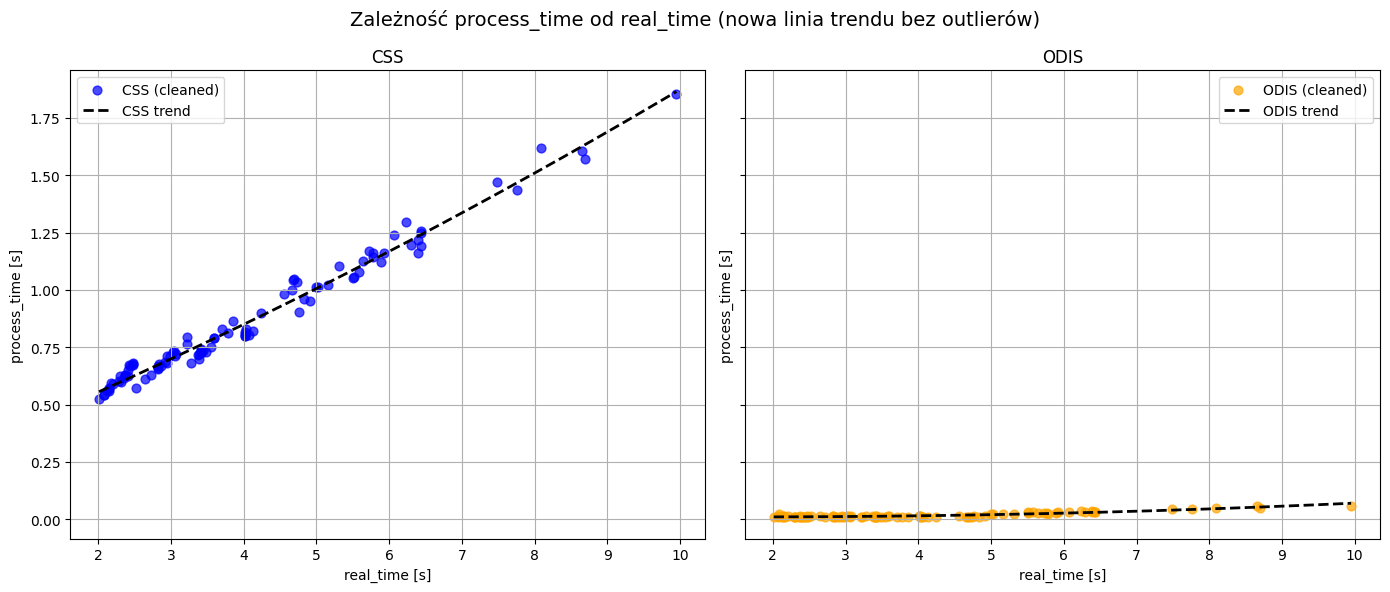

In [88]:
show_results_times('single_speaker')

CSS trend: y = 0.0015 * x² + 0.1481 * x + 0.3109
ODIS trend: y = -0.0265 * x² + 0.3993 * x + -0.1476


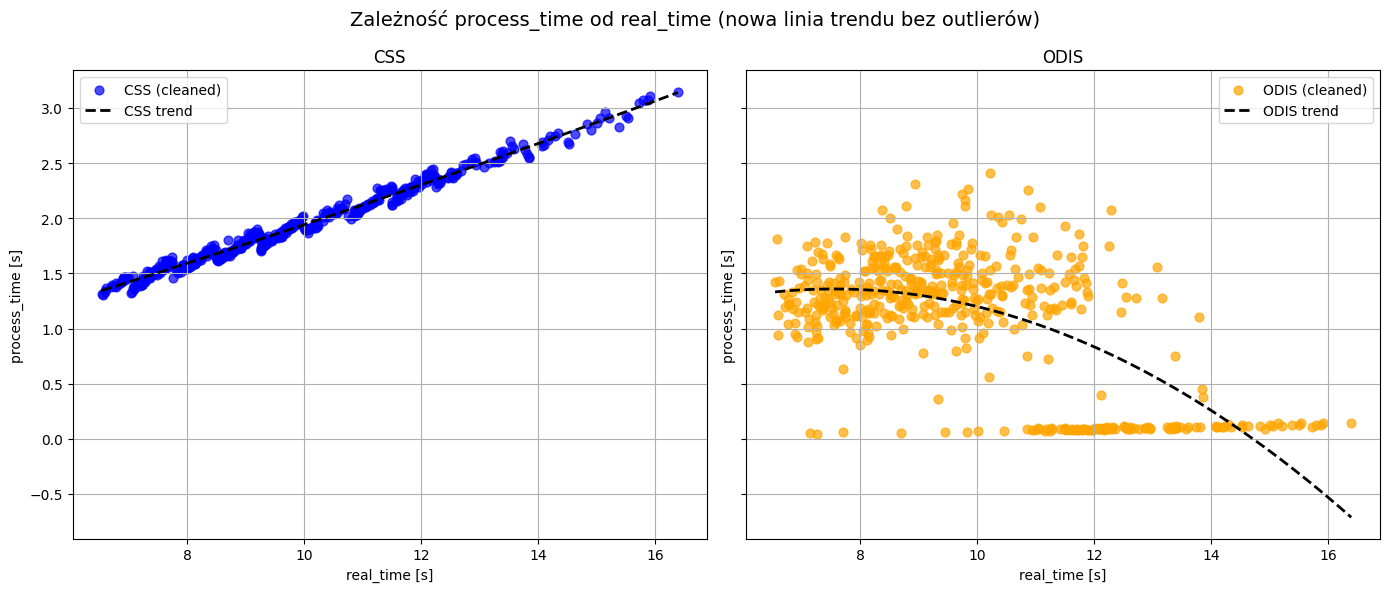

In [89]:
show_results_times('2_speakers')

CSS trend: y = -0.0376 * x² + 3.8800 * x + -61.3463
ODIS trend: y = -0.0003 * x² + 0.0461 * x + -0.3304


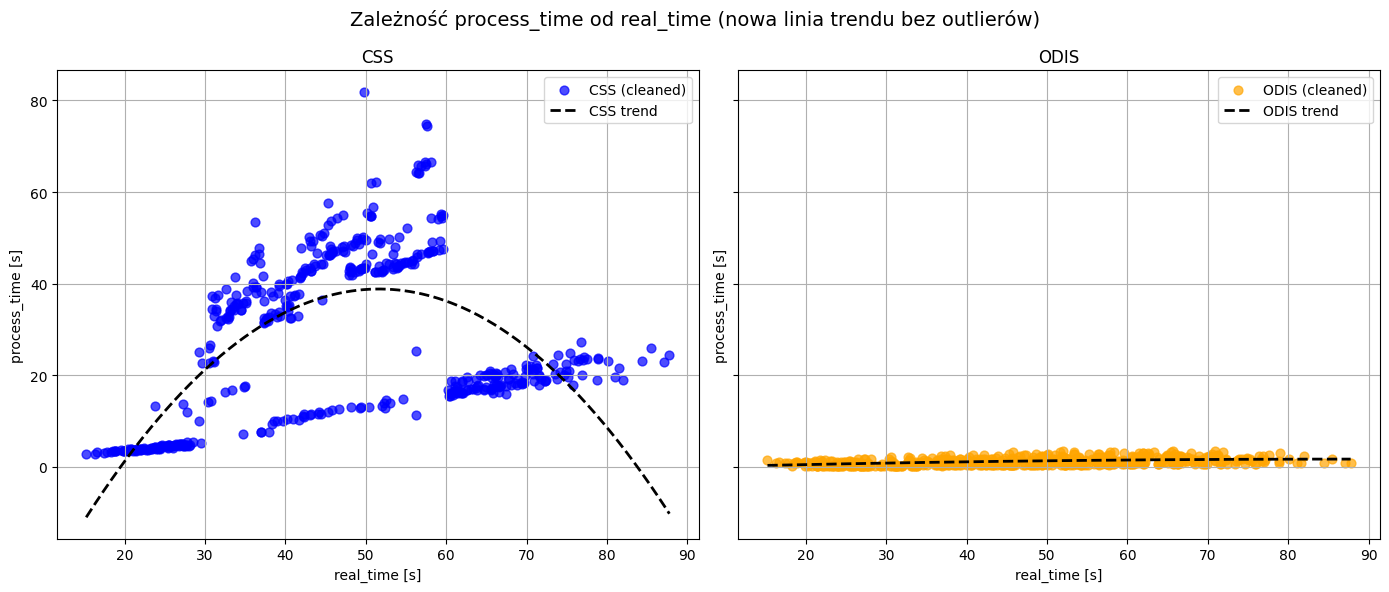

In [90]:
show_results_times('low_overlaping')

CSS trend: y = -0.0527 * x² + 7.2314 * x + -133.5704
ODIS trend: y = 0.0000 * x² + 0.0727 * x + -0.2247


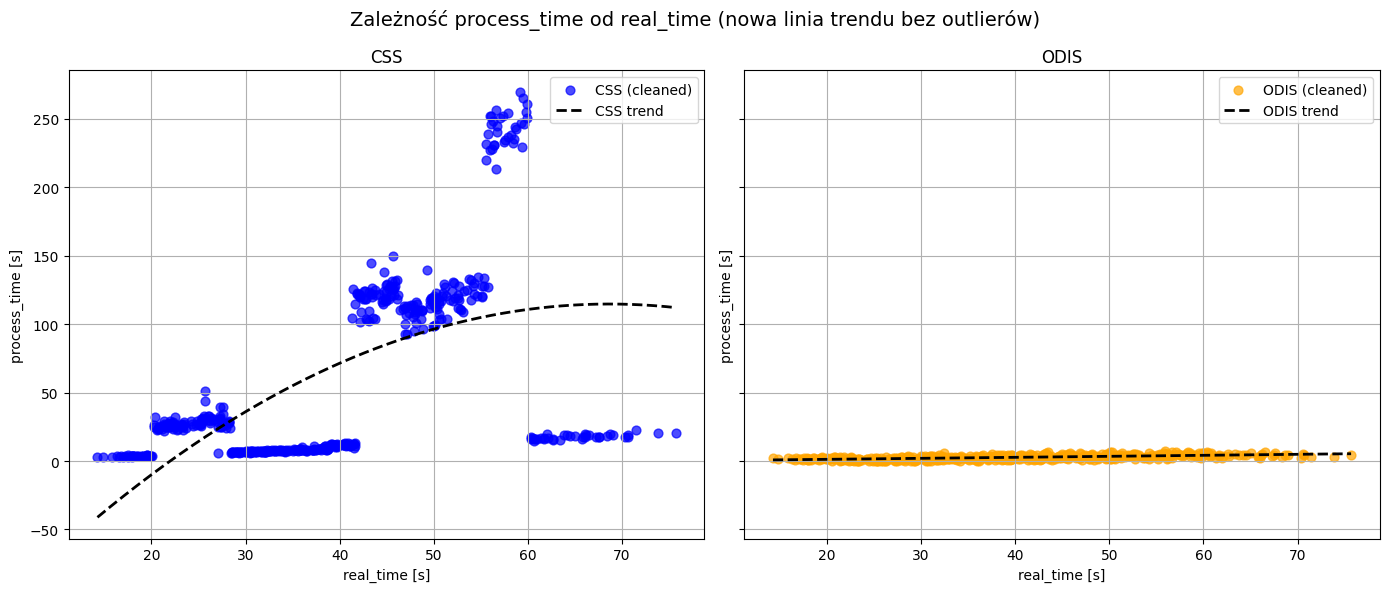

In [91]:
show_results_times('high_overlaping')

CSS trend: y = -0.0006 * x² + 0.4249 * x + -12.0727
ODIS trend: y = -0.0001 * x² + 0.0549 * x + -2.3461


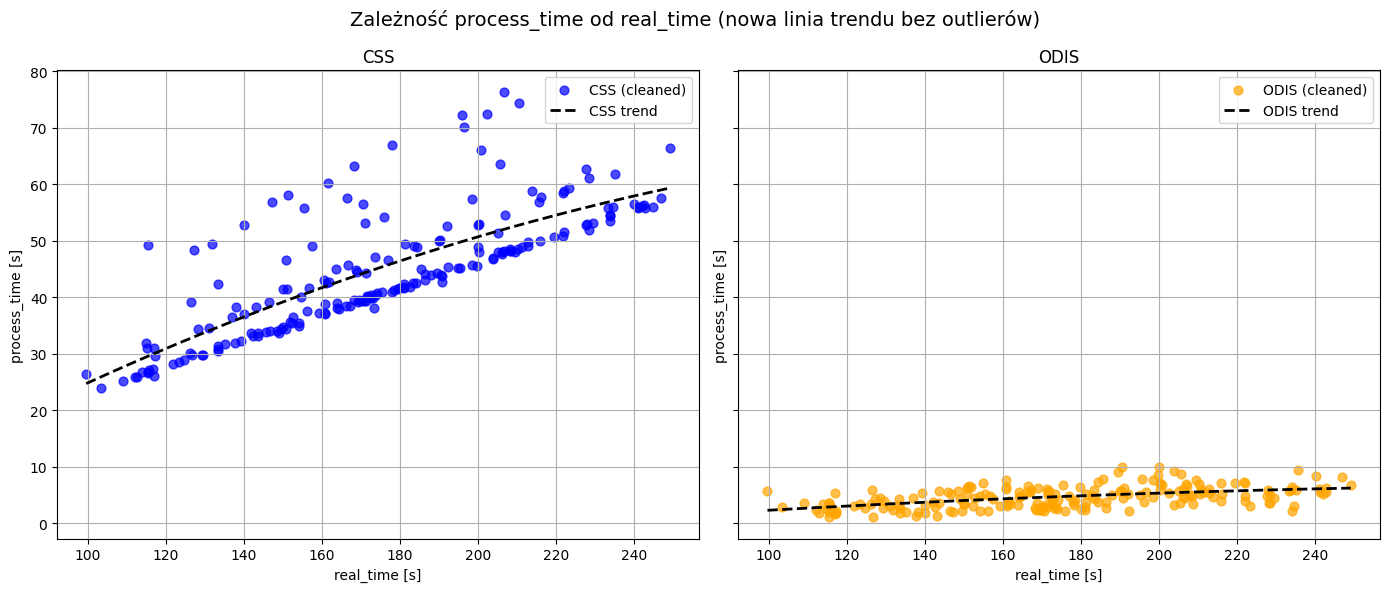

In [92]:
show_results_times('long_low_overlaping')

CSS trend: y = -0.0001 * x² + 0.2738 * x + -1.2320
ODIS trend: y = -0.0003 * x² + 0.1601 * x + -6.1988


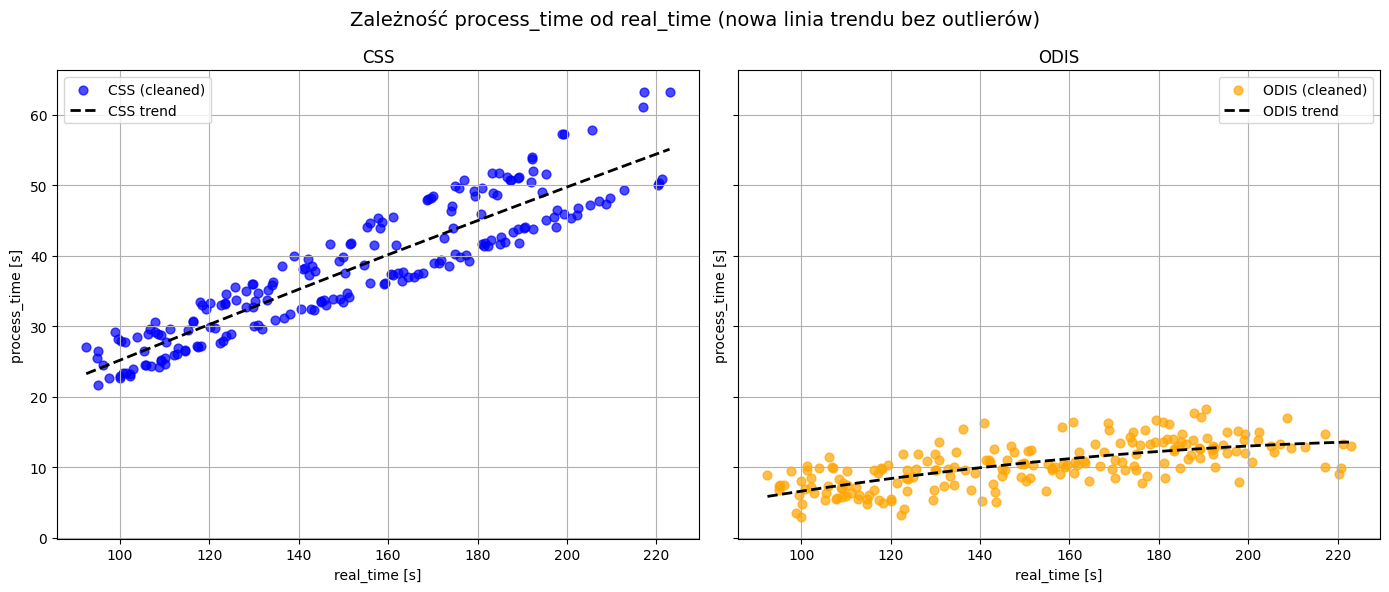

In [93]:
show_results_times('long_high_overlaping')

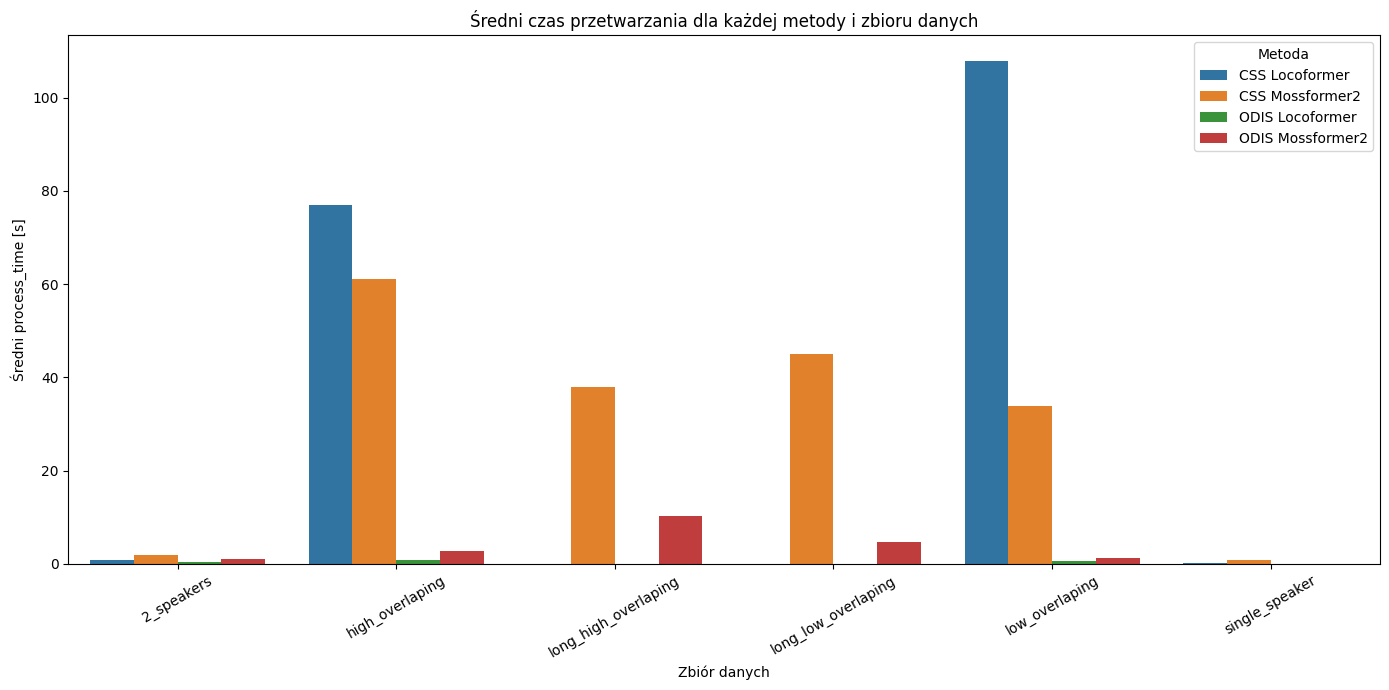

In [124]:
import seaborn as sns

# Przygotuj listę zbiorów i mapowanie nazw metod na czytelne etykiety
# Przygotuj listę zbiorów i mapowanie nazw metod na czytelne etykiety

datasets_mossformer = ['single_speaker', '2_speakers', 'low_overlaping', 'high_overlaping', 'long_low_overlaping', 'long_high_overlaping']
datasets_locoformer = ['single_speaker', '2_speakers', 'low_overlaping', 'high_overlaping']

method_labels = [
    ('CSS Mossformer2', 'css_mossformer2'),
    ('ODIS Mossformer2', 'odis_mossformer2'),
    ('CSS Locoformer', 'css_locoformer'),
    ('ODIS Locoformer', 'odis_locoformer')
]

def load_times_full(method_name, dataset):
    try:
        df = pd.read_csv(f'data/test/output/{method_name}/{dataset}/timing.csv')
        df['dataset'] = dataset
        df['method'] = method_name
        return df
    except FileNotFoundError:
        return None

# Wczytaj wszystkie czasy dla wszystkich metod i zbiorów
all_time_rows = []
for dataset in datasets_mossformer:
    for _, method in method_labels:
        df = load_times_full(method, dataset)
        if df is not None:
            all_time_rows.append(df)
if all_time_rows:
    df_times_full = pd.concat(all_time_rows, ignore_index=True)
else:
    df_times_full = pd.DataFrame()

# Dodaj długości próbek i overlapingów
def get_overlap_lengths(dataset, sr=16000):
    fragments = pd.read_csv(f'data/test/{dataset}/fragments.csv')
    overlaps = pd.read_csv(f'data/test/{dataset}/overlaps.csv')
    sample_ids = fragments['sample_id'].unique()
    lengths = []
    for sample_id in sample_ids:
        sample_frags = fragments[fragments['sample_id'] == sample_id]
        sample_len = int(sample_frags['end'].max())
        sample_overlaps = overlaps[overlaps['sample_id'] == sample_id]
        overlap_len = int(sample_overlaps['end'].sum() - sample_overlaps['start'].sum())
        no_overlap_len = sample_len - overlap_len
        lengths.append({
            'sample_id': sample_id,
            'total_len': sample_len / sr,
            'overlap_len': overlap_len / sr,
            'no_overlap_len': no_overlap_len / sr
        })
    return pd.DataFrame(lengths)

lengths_all = []
for dataset in datasets_mossformer:
    lengths_df = get_overlap_lengths(dataset)
    lengths_df['dataset'] = dataset
    lengths_all.append(lengths_df)
df_lengths_full = pd.concat(lengths_all, ignore_index=True)

# Połącz dane czasowe z długościami
df_times_full = pd.merge(df_times_full, df_lengths_full, on=['dataset', 'sample_id'], how='left')

# Przypisz czytelne etykiety metod
method_label_map = {
    'css_mossformer2': 'CSS Mossformer2',
    'odis_mossformer2': 'ODIS Mossformer2',
    'css_locoformer': 'CSS Locoformer',
    'odis_locoformer': 'ODIS Locoformer'
}
df_times_full['method_label'] = df_times_full['method'].map(method_label_map)

# Pokaż tylko process_time i daj na osobne osie metody i zbiory danych

import matplotlib.pyplot as plt

plt.figure(figsize=(14, 7))
sns.barplot(
    data=mean_times,
    x='dataset',
    y='process_time',
    hue='method_label'
)
plt.ylabel('Średni process_time [s]')
plt.xlabel('Zbiór danych')
plt.title('Średni czas przetwarzania dla każdej metody i zbioru danych')
plt.legend(title='Metoda')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

In [127]:
# Oblicz średni RTF (process_time / real_time) dla każdego zbioru i metody
df_times_full['RTF'] = df_times_full['process_time'] / df_times_full['real_time']
mean_rtf = df_times_full.groupby(['dataset', 'method_label'])['RTF'].mean().unstack()
mean_rtf

method_label,CSS Locoformer,CSS Mossformer2,ODIS Locoformer,ODIS Mossformer2
dataset,,,,
2_speakers,0.080847,0.195814,0.042972,0.123726
high_overlaping,1.715270,1.344545,0.022780,0.067025
long_high_overlaping,NaN,0.250997,NaN,0.068176
long_low_overlaping,NaN,0.257549,NaN,0.026675
low_overlaping,2.024906,0.703276,0.013776,0.026032
single_speaker,0.068356,0.225122,0.006261,0.006476


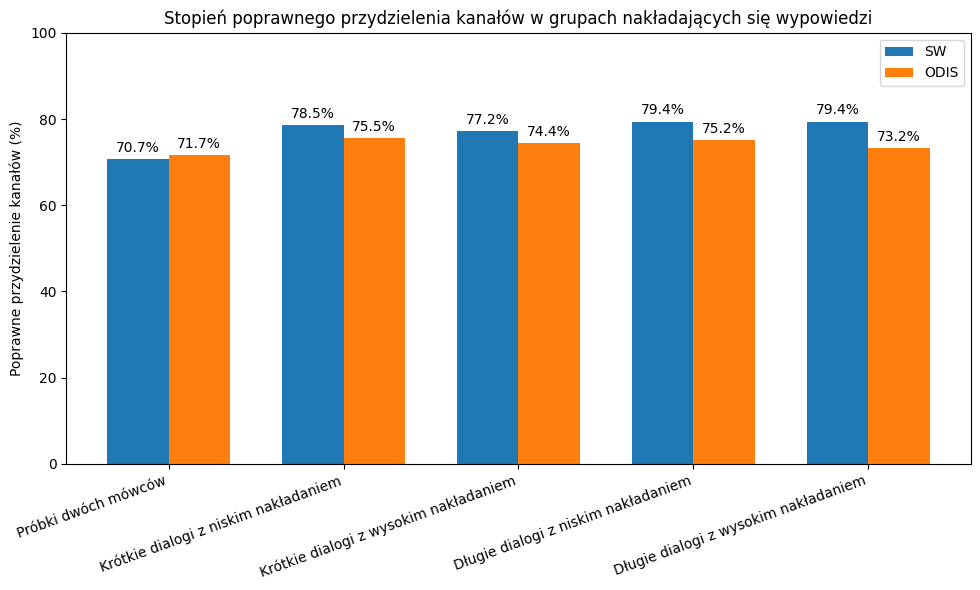

In [130]:
import matplotlib.pyplot as plt
import numpy as np

# Dane z tabeli
labels = [
    'Próbki dwóch mówców',
    'Krótkie dialogi z niskim nakładaniem',
    'Krótkie dialogi z wysokim nakładaniem',
    'Długie dialogi z niskim nakładaniem',
    'Długie dialogi z wysokim nakładaniem'
]

css_values = [70.7, 78.5, 77.2, 79.4, 79.4]
odis_values = [71.7, 75.5, 74.4, 75.2, 73.2]

# Konfiguracja wykresu
x = np.arange(len(labels))  # etykiety na osi X
width = 0.35  # szerokość słupków

fig, ax = plt.subplots(figsize=(10, 6))
rects1 = ax.bar(x - width/2, css_values, width, label='SW', color='#1f77b4')
rects2 = ax.bar(x + width/2, odis_values, width, label='ODIS', color='#ff7f0e')

# Etykiety i tytuł
ax.set_ylabel('Poprawne przydzielenie kanałów (%)')
ax.set_title('Stopień poprawnego przydzielenia kanałów w grupach nakładających się wypowiedzi')
ax.set_xticks(x)
ax.set_ylim(0, 100)

ax.set_xticklabels(labels, rotation=20, ha='right')
ax.legend()

# Dodanie wartości nad słupkami
def autolabel(rects):
    """Dodaje etykiety z wartościami nad słupkami."""
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height:.1f}%',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3),  # przesunięcie w pionie
                    textcoords="offset points",
                    ha='center', va='bottom')

autolabel(rects1)
autolabel(rects2)

plt.tight_layout()
plt.show()


In [126]:
mean_times

,dataset,method_label,process_time,real_time,total_len,overlap_len,no_overlap_len
0,2_speakers,CSS Locoformer,0.804016,9.837847,9.837815,3.781934,6.055881
1,2_speakers,CSS Mossformer2,1.919381,9.837814,9.837815,3.781934,6.055881
2,2_speakers,ODIS Locoformer,0.389914,9.837814,9.837815,3.781934,6.055881
3,2_speakers,ODIS Mossformer2,1.107878,9.837814,9.837815,3.781934,6.055881
4,high_overlaping,CSS Locoformer,76.891731,39.620639,39.620609,6.627255,32.993354
5,high_overlaping,CSS Mossformer2,60.994519,39.620609,39.620609,6.627255,32.993354
6,high_overlaping,ODIS Locoformer,0.910988,39.620609,39.620609,6.627255,32.993354
7,high_overlaping,ODIS Mossformer2,2.673572,39.620609,39.620609,6.627255,32.993354
8,long_high_overlaping,CSS Mossformer2,37.930032,151.289623,151.289623,26.558394,124.731229
9,long_high_overlaping,ODIS Mossformer2,10.281329,151.289623,151.289623,26.558394,124.731229


Zrób wykres korelacji gdzie w osi Y będą czasy generowania próbek za pomocą CSS i ODIS z Mossformer2 i Locoformer. Oś x powinna mieć cechy typu Długość próbki, długość części z overlapingiem, długość części bez overlapingu



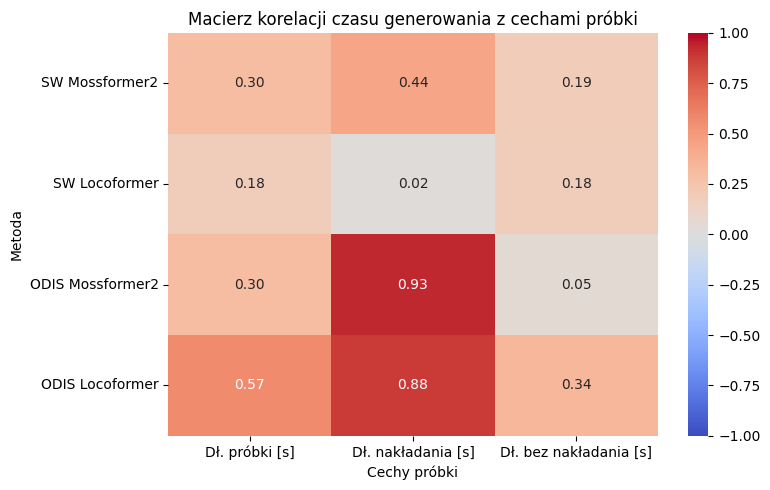

In [131]:
import seaborn as sns

import matplotlib.pyplot as plt

def get_overlap_lengths(dataset, sr=16000):
    # Wczytaj fragmenty i overlapy
    fragments = pd.read_csv(f'data/test/{dataset}/fragments.csv')
    overlaps = pd.read_csv(f'data/test/{dataset}/overlaps.csv')
    sample_ids = fragments['sample_id'].unique()
    lengths = []
    for sample_id in sample_ids:
        # Długość próbki
        sample_frags = fragments[fragments['sample_id'] == sample_id]
        sample_len = int(sample_frags['end'].max())
        # Długość overlaping
        sample_overlaps = overlaps[overlaps['sample_id'] == sample_id]
        overlap_len = int(sample_overlaps['end'].sum() - sample_overlaps['start'].sum())
        # Długość bez overlapu
        no_overlap_len = sample_len - overlap_len
        lengths.append({
            'sample_id': sample_id,
            'total_len': sample_len / sr,
            'overlap_len': overlap_len / sr,
            'no_overlap_len': no_overlap_len / sr
        })
    return pd.DataFrame(lengths)

def load_times(method_name, dataset):
    df = pd.read_csv(f'data/test/output/{method_name}/{dataset}/timing.csv')
    return df

datasets = ['low_overlaping', 'high_overlaping']
methods = [
    ('css_mossformer2', 'CSS Mossformer2'),
    ('odis_mossformer2', 'ODIS Mossformer2'),
    ('css_locoformer', 'CSS Locoformer'),
    ('odis_locoformer', 'ODIS Locoformer')
]

all_rows = []
for dataset in datasets:
    lengths_df = get_overlap_lengths(dataset)
    for method, method_label in methods:
        try:
            times_df = load_times(method, dataset)
        except FileNotFoundError:
            continue
        merged = pd.merge(times_df, lengths_df, left_on='sample_id', right_on='sample_id')
        for _, row in merged.iterrows():
            all_rows.append({
                'dataset': dataset,
                'method': method_label,
                'process_time': row['process_time'],
                'real_time': row['real_time'],
                'total_len': row['total_len'],
                'overlap_len': row['overlap_len'],
                'no_overlap_len': row['no_overlap_len']
            })

df_corr = pd.DataFrame(all_rows)

# Przygotuj dane: wybierz tylko interesujące kolumny i przemapuj metody na krótsze nazwy
df_corr_plot = df_corr.copy()
df_corr_plot['method'] = df_corr_plot['method'].replace({
    'CSS Mossformer2': 'SW Mossformer2',
    'ODIS Mossformer2': 'ODIS Mossformer2',
    'CSS Locoformer': 'SW Locoformer',
    'ODIS Locoformer': 'ODIS Locoformer'
})

# Pivot: wiersze - metoda, kolumny - cecha, wartości - korelacja z process_time
features = ['total_len', 'overlap_len', 'no_overlap_len']
feature_labels = ['Dł. próbki [s]', 'Dł. nakładania [s]', 'Dł. bez nakładania [s]']
method_labels = ['SW Mossformer2', 'SW Locoformer', 'ODIS Mossformer2', 'ODIS Locoformer']

corr_data = []
for method in method_labels:
    sub = df_corr_plot[df_corr_plot['method'] == method]
    corr_row = []
    for feat in features:
        corr = sub[['process_time', feat]].corr().iloc[0,1]
        corr_row.append(corr)
    corr_data.append(corr_row)

corr_matrix = pd.DataFrame(corr_data, index=method_labels, columns=feature_labels)

plt.figure(figsize=(8, 5))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1, fmt=".2f")
plt.xlabel('Cechy próbki')
plt.ylabel('Metoda')
plt.title('Macierz korelacji czasu generowania z cechami próbki')
plt.tight_layout()
plt.show()

In [ ]:
import glob
import json

def load_results(method_name, dataset):
    results = []
    path = f'results/{method_name}_{dataset}.jsonl'
    with open(path, 'r') as f:
        for line in f:
            results.append(json.loads(line))
    return results

datasets = ['single_speaker', '2_speakers', 'low_overlaping', 'high_overlaping', 'long_low_overlaping', 'long_high_overlaping']
methods = ['css_mossformer2', 'odis_mossformer2']

rows_all = []
rows_wo = []
rows_no = []

for dataset in datasets:
    for method in methods:
        results = load_results(method, dataset)
        # normal
        si_sdr = np.mean([r['SI_SDR'] for r in results if r['SI_SDR'] is not None])
        stoi = np.mean([r['STOI'] for r in results if r['STOI'] is not None])
        si_mss = np.mean([r['SI_MSS'] for r in results if r['SI_MSS'] is not None])
        si_med = np.mean([r['SI_MED'] for r in results if r['SI_MED'] is not None])
        rows_all.append({'dataset': dataset, 'method': method, 'SI_SDR': si_sdr, 'STOI': stoi, 'SI_MSS': si_mss, 'SI_MED': si_med})

        # wo
        si_sdr_wo = np.mean([r['wo']['SI_SDR'] for r in results if r['wo']['SI_SDR'] is not None])
        stoi_wo = np.mean([r['wo']['STOI'] for r in results if r['wo']['STOI'] is not None])
        si_mss_wo = np.mean([r['wo']['SI_MSS'] for r in results if r['wo']['SI_MSS'] is not None])
        si_med_wo = np.mean([r['wo']['SI_MED'] for r in results if r['wo']['SI_MED'] is not None])
        rows_wo.append({'dataset': dataset, 'method': method, 'SI_SDR': si_sdr_wo, 'STOI': stoi_wo, 'SI_MSS': si_mss_wo, 'SI_MED': si_med_wo})

        # no
        si_sdr_no = np.mean([r['no']['SI_SDR'] for r in results if r['no']['SI_SDR'] is not None])
        stoi_no = np.mean([r['no']['STOI'] for r in results if r['no']['STOI'] is not None])
        si_mss_no = np.mean([r['no']['SI_MSS'] for r in results if r['no']['SI_MSS'] is not None])
        si_med_no = np.mean([r['no']['SI_MED'] for r in results if r['no']['SI_MED'] is not None])
        rows_no.append({'dataset': dataset, 'method': method, 'SI_SDR': si_sdr_no, 'STOI': stoi_no, 'SI_MSS': si_mss_no, 'SI_MED': si_med_no})

df_all = pd.DataFrame(rows_all)
df_wo = pd.DataFrame(rows_wo)
df_no = pd.DataFrame(rows_no)

c:\Studia\.conda\Lib\site-packages\numpy\core\fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
c:\Studia\.conda\Lib\site-packages\numpy\core\_methods.py:129: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


In [113]:
import glob
import json

def load_results(method_name, dataset):
    results = []
    path = f'results/{method_name}_{dataset}.jsonl'
    with open(path, 'r') as f:
        for line in f:
            results.append(json.loads(line))
    return results

datasets = ['single_speaker', '2_speakers', 'low_overlaping', 'high_overlaping']
methods = ['css_locoformer', 'odis_locoformer']

rows_all = []
rows_wo = []
rows_no = []

for dataset in datasets:
    for method in methods:
        results = load_results(method, dataset)
        # normal
        si_sdr = np.mean([r['SI_SDR'] for r in results if r['SI_SDR'] is not None])
        stoi = np.mean([r['STOI'] for r in results if r['STOI'] is not None])
        si_mss = np.mean([r['SI_MSS'] for r in results if r['SI_MSS'] is not None])
        si_med = np.mean([r['SI_MED'] for r in results if r['SI_MED'] is not None])
        rows_all.append({'dataset': dataset, 'method': method, 'SI_SDR': si_sdr, 'STOI': stoi, 'SI_MSS': si_mss, 'SI_MED': si_med})

        # wo
        si_sdr_wo = np.mean([r['wo']['SI_SDR'] for r in results if r['wo']['SI_SDR'] is not None])
        stoi_wo = np.mean([r['wo']['STOI'] for r in results if r['wo']['STOI'] is not None])
        si_mss_wo = np.mean([r['wo']['SI_MSS'] for r in results if r['wo']['SI_MSS'] is not None])
        si_med_wo = np.mean([r['wo']['SI_MED'] for r in results if r['wo']['SI_MED'] is not None])
        rows_wo.append({'dataset': dataset, 'method': method, 'SI_SDR': si_sdr_wo, 'STOI': stoi_wo, 'SI_MSS': si_mss_wo, 'SI_MED': si_med_wo})

        # no
        si_sdr_no = np.mean([r['no']['SI_SDR'] for r in results if r['no']['SI_SDR'] is not None])
        stoi_no = np.mean([r['no']['STOI'] for r in results if r['no']['STOI'] is not None])
        si_mss_no = np.mean([r['no']['SI_MSS'] for r in results if r['no']['SI_MSS'] is not None])
        si_med_no = np.mean([r['no']['SI_MED'] for r in results if r['no']['SI_MED'] is not None])
        rows_no.append({'dataset': dataset, 'method': method, 'SI_SDR': si_sdr_no, 'STOI': stoi_no, 'SI_MSS': si_mss_no, 'SI_MED': si_med_no})

df_all_loco = pd.DataFrame(rows_all)
df_wo_loco = pd.DataFrame(rows_wo)
df_no_loco = pd.DataFrame(rows_no)

c:\Studia\.conda\Lib\site-packages\numpy\core\fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
c:\Studia\.conda\Lib\site-packages\numpy\core\_methods.py:129: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


In [16]:
import glob
import json

def load_results(method_name, dataset):
    results = []
    path = f'results/{method_name}_{dataset}.jsonl'
    with open(path, 'r') as f:
        for line in f:
            results.append(json.loads(line))
    return results

datasets = ['low_overlaping', 'high_overlaping']
methods = ['odis_mossformer2', 'odis_mossformer2_with_knowledge']

rows_all = []
rows_wo = []
rows_no = []

for dataset in datasets:
    for method in methods:
        results = load_results(method, dataset)
        # normal
        si_sdr = np.mean([r['SI_SDR'] for r in results if r['SI_SDR'] is not None])
        stoi = np.mean([r['STOI'] for r in results if r['STOI'] is not None])
        si_mss = np.mean([r['SI_MSS'] for r in results if r['SI_MSS'] is not None])
        si_med = np.mean([r['SI_MED'] for r in results if r['SI_MED'] is not None])
        rows_all.append({'dataset': dataset, 'method': method, 'SI_SDR': si_sdr, 'STOI': stoi, 'SI_MSS': si_mss, 'SI_MED': si_med})

        # wo
        si_sdr_wo = np.mean([r['wo']['SI_SDR'] for r in results if r['wo']['SI_SDR'] is not None])
        stoi_wo = np.mean([r['wo']['STOI'] for r in results if r['wo']['STOI'] is not None])
        si_mss_wo = np.mean([r['wo']['SI_MSS'] for r in results if r['wo']['SI_MSS'] is not None])
        si_med_wo = np.mean([r['wo']['SI_MED'] for r in results if r['wo']['SI_MED'] is not None])
        rows_wo.append({'dataset': dataset, 'method': method, 'SI_SDR': si_sdr_wo, 'STOI': stoi_wo, 'SI_MSS': si_mss_wo, 'SI_MED': si_med_wo})

        # no
        si_sdr_no = np.mean([r['no']['SI_SDR'] for r in results if r['no']['SI_SDR'] is not None])
        stoi_no = np.mean([r['no']['STOI'] for r in results if r['no']['STOI'] is not None])
        si_mss_no = np.mean([r['no']['SI_MSS'] for r in results if r['no']['SI_MSS'] is not None])
        si_med_no = np.mean([r['no']['SI_MED'] for r in results if r['no']['SI_MED'] is not None])
        rows_no.append({'dataset': dataset, 'method': method, 'SI_SDR': si_sdr_no, 'STOI': stoi_no, 'SI_MSS': si_mss_no, 'SI_MED': si_med_no})

df_all_kn = pd.DataFrame(rows_all)
df_wo_kn = pd.DataFrame(rows_wo)
df_no_kn = pd.DataFrame(rows_no)

In [80]:
df_all

,dataset,method,SI_SDR,STOI,SI_MSS,SI_MED
0,single_speaker,css_mossformer2,34.559682,0.983561,0.915112,0.960786
1,single_speaker,odis_mossformer2,150.477330,0.998832,0.995496,0.995307
2,2_speakers,css_mossformer2,17.664033,0.952169,0.808006,0.831721
3,2_speakers,odis_mossformer2,40.056442,0.934118,0.841160,0.788305
4,low_overlaping,css_mossformer2,13.190301,0.941190,0.755434,0.747759
5,low_overlaping,odis_mossformer2,60.615655,0.987545,0.940632,0.879809
6,high_overlaping,css_mossformer2,8.085868,0.902728,0.668307,0.618312
7,high_overlaping,odis_mossformer2,19.990173,0.963622,0.874156,0.753294
8,long_low_overlaping,css_mossformer2,7.230253,0.909691,0.762784,0.686089
9,long_low_overlaping,odis_mossformer2,17.009935,0.987064,0.915429,0.832864


In [114]:
df_all_loco

,dataset,method,SI_SDR,STOI,SI_MSS,SI_MED
0,single_speaker,css_locoformer,2.500491,0.892976,0.350739,0.489243
1,single_speaker,odis_locoformer,150.393492,0.996690,0.992713,0.991914
2,2_speakers,css_locoformer,6.759459,0.902914,0.459566,0.576776
3,2_speakers,odis_locoformer,22.367177,0.899067,0.664758,0.346159
4,low_overlaping,css_locoformer,3.539958,0.891105,0.400245,0.481180
5,low_overlaping,odis_locoformer,49.258964,0.978837,0.898714,0.606632
6,high_overlaping,css_locoformer,2.740947,0.841146,0.403953,0.434648
7,high_overlaping,odis_locoformer,-2.863683,0.940276,0.764249,0.215451


In [5]:
import hashlib
hashlib.md5("Piotrowski283344".encode('utf-8')).hexdigest()[:6]


'5a2af8'

In [81]:
df_wo

,dataset,method,SI_SDR,STOI,SI_MSS,SI_MED
0,single_speaker,css_mossformer2,NaN,NaN,NaN,NaN
1,single_speaker,odis_mossformer2,NaN,NaN,NaN,NaN
2,2_speakers,css_mossformer2,15.408860,0.931688,0.786846,0.808689
3,2_speakers,odis_mossformer2,13.005911,0.891583,0.758967,0.741879
4,low_overlaping,css_mossformer2,4.044441,0.748875,0.665142,0.459200
5,low_overlaping,odis_mossformer2,12.304640,0.889242,0.755436,0.713023
6,high_overlaping,css_mossformer2,3.744486,0.758352,0.667483,0.443896
7,high_overlaping,odis_mossformer2,10.647564,0.884067,0.744871,0.673034
8,long_low_overlaping,css_mossformer2,6.905014,0.832335,0.708644,0.614522
9,long_low_overlaping,odis_mossformer2,10.104433,0.884195,0.742431,0.650227


In [115]:
df_wo_loco

,dataset,method,SI_SDR,STOI,SI_MSS,SI_MED
0,single_speaker,css_locoformer,NaN,NaN,NaN,NaN
1,single_speaker,odis_locoformer,NaN,NaN,NaN,NaN
2,2_speakers,css_locoformer,6.542382,0.868937,0.471509,0.557539
3,2_speakers,odis_locoformer,2.540461,0.837075,0.479791,0.467349
4,low_overlaping,css_locoformer,0.053887,0.683261,0.430546,0.316004
5,low_overlaping,odis_locoformer,2.010487,0.828756,0.482333,0.450630
6,high_overlaping,css_locoformer,0.316834,0.693221,0.432646,0.325803
7,high_overlaping,odis_locoformer,0.213046,0.824747,0.478306,0.401121


In [82]:
df_no

,dataset,method,SI_SDR,STOI,SI_MSS,SI_MED
0,single_speaker,css_mossformer2,34.559682,0.983561,0.915112,0.960786
1,single_speaker,odis_mossformer2,150.477330,0.998832,0.995496,0.995307
2,2_speakers,css_mossformer2,25.301904,0.978783,0.840560,0.881891
3,2_speakers,odis_mossformer2,92.060190,0.990138,0.963215,0.932871
4,low_overlaping,css_mossformer2,15.689933,0.960556,0.760096,0.789110
5,low_overlaping,odis_mossformer2,91.076181,0.997000,0.982623,0.970771
6,high_overlaping,css_mossformer2,11.999150,0.962637,0.662157,0.709196
7,high_overlaping,odis_mossformer2,56.071197,0.997082,0.978314,0.951067
8,long_low_overlaping,css_mossformer2,7.604996,0.918938,0.770247,0.700010
9,long_low_overlaping,odis_mossformer2,46.559629,0.998146,0.976706,0.969147


In [116]:
df_no_loco

,dataset,method,SI_SDR,STOI,SI_MSS,SI_MED
0,single_speaker,css_locoformer,2.500491,0.892976,0.350739,0.489243
1,single_speaker,odis_locoformer,150.393492,0.996690,0.992713,0.991914
2,2_speakers,css_locoformer,8.379120,0.946069,0.448424,0.633272
3,2_speakers,odis_locoformer,80.562648,0.971555,0.902257,0.773057
4,low_overlaping,css_locoformer,4.080299,0.912973,0.397905,0.505297
5,low_overlaping,odis_locoformer,83.874207,0.993583,0.970458,0.915392
6,high_overlaping,css_locoformer,4.057074,0.904159,0.393271,0.492826
7,high_overlaping,odis_locoformer,42.992844,0.988388,0.950635,0.838049


In [17]:
df_all_kn

,dataset,method,SI_SDR,STOI,SI_MSS,SI_MED
0,low_overlaping,odis_mossformer2,60.615655,0.987545,0.940632,0.879809
1,low_overlaping,odis_mossformer2_with_knowledge,71.359176,0.995455,0.956108,0.898511
2,high_overlaping,odis_mossformer2,19.990173,0.963622,0.874156,0.753294
3,high_overlaping,odis_mossformer2_with_knowledge,21.947913,0.983493,0.893522,0.764986


In [18]:
df_no_kn

,dataset,method,SI_SDR,STOI,SI_MSS,SI_MED
0,low_overlaping,odis_mossformer2,91.076181,0.997000,0.982623,0.970771
1,low_overlaping,odis_mossformer2_with_knowledge,151.923094,1.000000,1.000000,1.000000
2,high_overlaping,odis_mossformer2,56.071197,0.997082,0.978314,0.951067
3,high_overlaping,odis_mossformer2_with_knowledge,151.925627,1.000000,1.000000,1.000000


In [19]:
df_wo_kn

,dataset,method,SI_SDR,STOI,SI_MSS,SI_MED
0,low_overlaping,odis_mossformer2,12.304640,0.889242,0.755436,0.713023
1,low_overlaping,odis_mossformer2_with_knowledge,15.755575,0.948768,0.804578,0.806741
2,high_overlaping,odis_mossformer2,10.647564,0.884067,0.744871,0.673034
3,high_overlaping,odis_mossformer2_with_knowledge,13.248410,0.944795,0.791069,0.738442


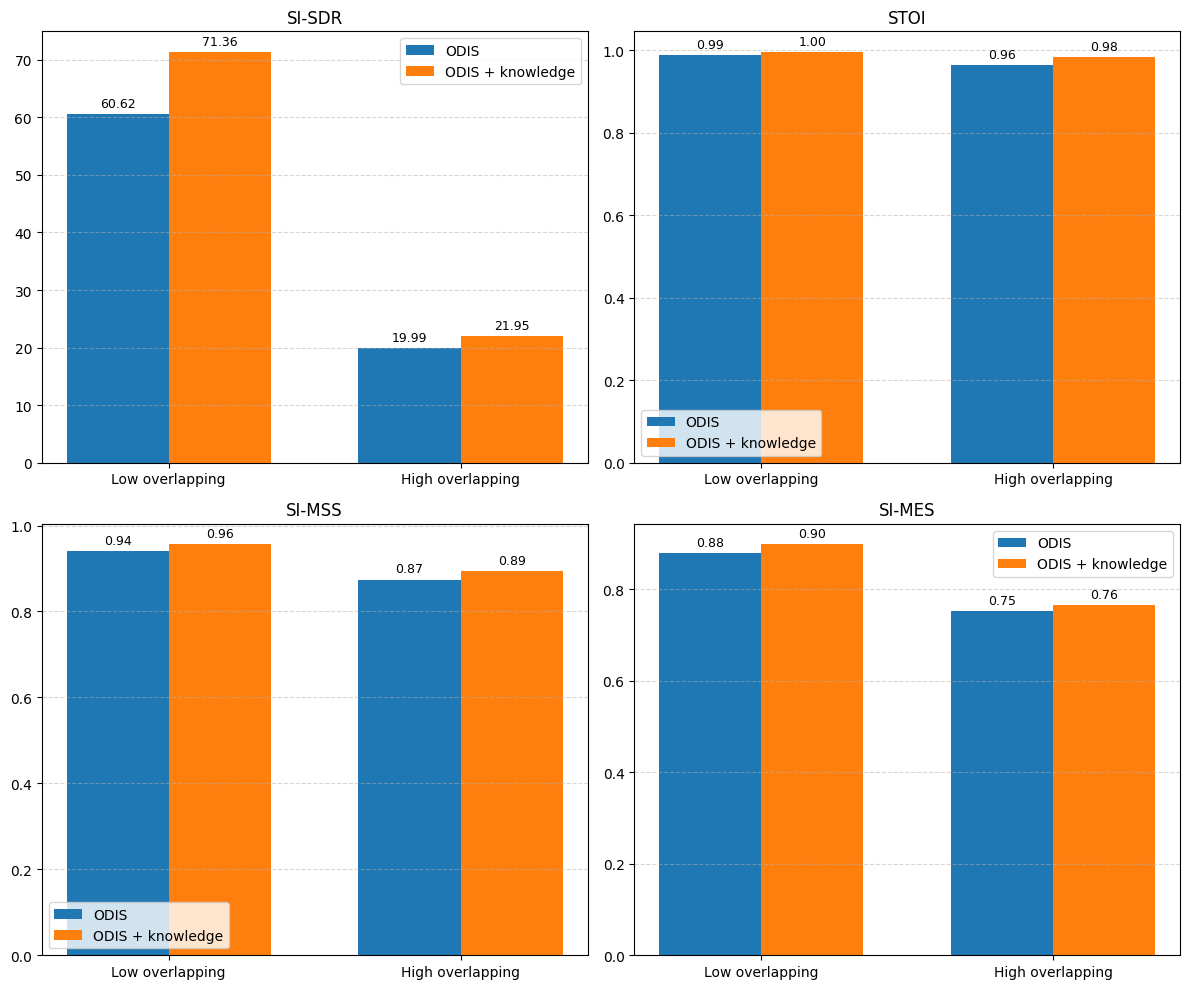

In [26]:
import numpy as np

import matplotlib.pyplot as plt

# Wybierz metryki i ich etykiety
metrics = [
    ('SI_SDR', 'SI-SDR'),
    ('STOI', 'STOI'),
    ('SI_MSS', 'SI-MSS'),
    ('SI_MED', 'SI-MES')
]

datasets_plot = ['low_overlaping', 'high_overlaping']
methods_plot = ['odis_mossformer2', 'odis_mossformer2_with_knowledge']
method_labels = {
    'odis_mossformer2': 'ODIS',
    'odis_mossformer2_with_knowledge': 'ODIS + knowledge'
}
dataset_labels = {
    'low_overlaping': 'Low overlapping',
    'high_overlaping': 'High overlapping'
}

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

for idx, (metric, metric_label) in enumerate(metrics):
    ax = axes[idx]
    width = 0.35
    x = np.arange(len(datasets_plot))
    values = []
    for method in methods_plot:
        vals = []
        for dataset in datasets_plot:
            row = df_all_kn[(df_all_kn['dataset'] == dataset) & (df_all_kn['method'] == method)]
            if not row.empty:
                vals.append(row.iloc[0][metric])
            else:
                vals.append(np.nan)
        values.append(vals)
    rects1 = ax.bar(x - width/2, values[0], width, label=method_labels[methods_plot[0]], color='#1f77b4')
    rects2 = ax.bar(x + width/2, values[1], width, label=method_labels[methods_plot[1]], color='#ff7f0e')
    ax.set_xticks(x)
    ax.set_xticklabels([dataset_labels[d] for d in datasets_plot])
    ax.set_title(metric_label)
    ax.legend()
    ax.grid(axis='y', linestyle='--', alpha=0.5)
    # Dodaj wartości nad słupkami
    for rects in [rects1, rects2]:
        for rect in rects:
            height = rect.get_height()
            if not np.isnan(height):
                ax.annotate(f'{height:.2f}',
                            xy=(rect.get_x() + rect.get_width() / 2, height),
                            xytext=(0, 3),
                            textcoords="offset points",
                            ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

C:\Users\wikto\AppData\Local\Temp\ipykernel_7596\31972847.py:61: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(
C:\Users\wikto\AppData\Local\Temp\ipykernel_7596\31972847.py:81: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels())
C:\Users\wikto\AppData\Local\Temp\ipykernel_7596\31972847.py:61: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(
C:\Users\wikto\AppData\Local\Temp\ipykernel_7596\31972847.py:81: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels())
C:\Users\wikto\AppData\Local\Temp\ipykernel_7596\31972847.py:61: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(
C:\Users\

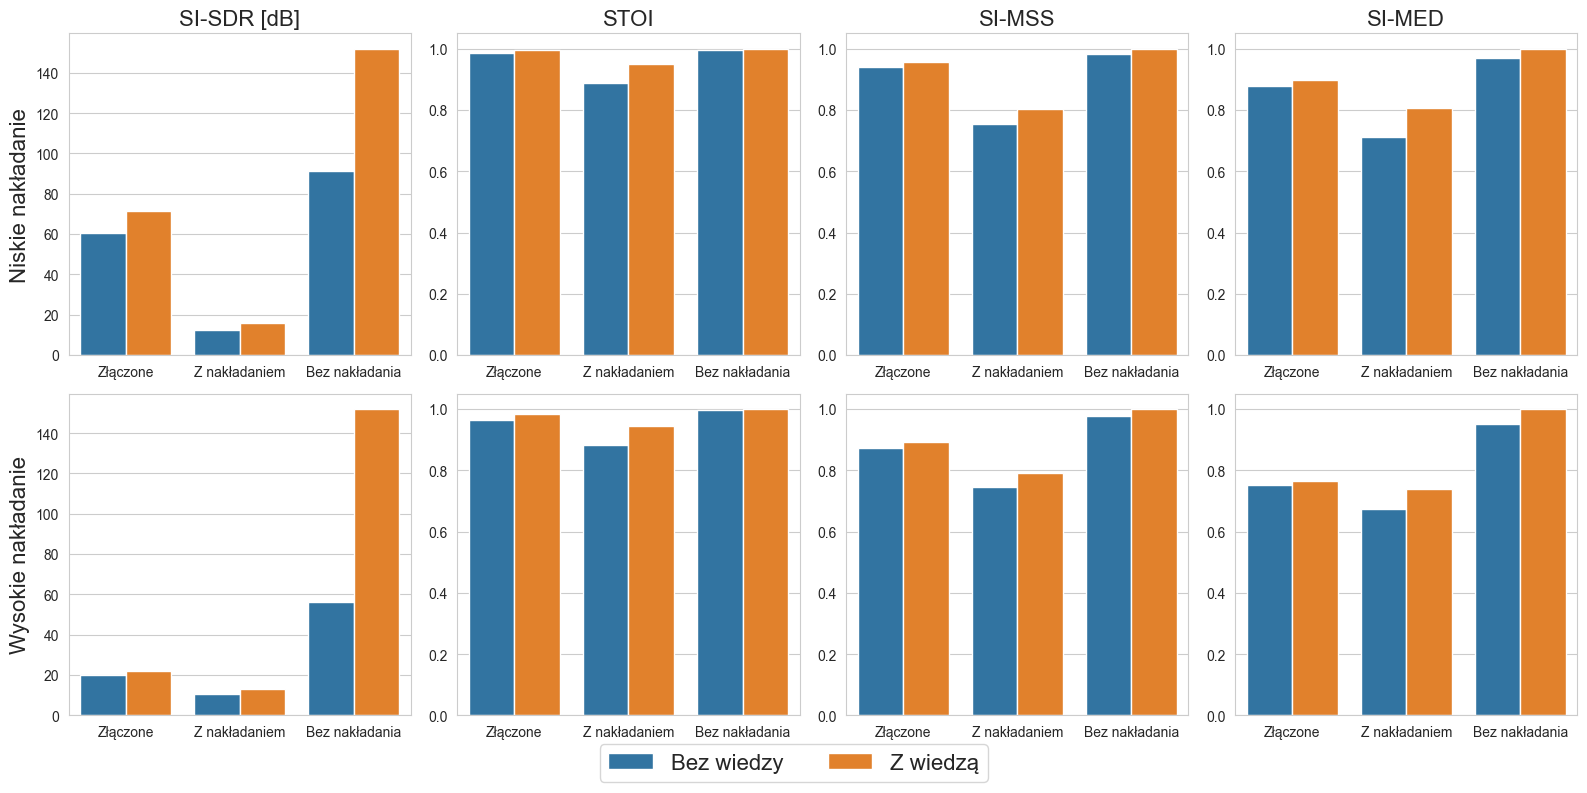

In [54]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# Dodaj kolumnę "source"
df_all_kn['source'] = 'all_kn'
df_no_kn['source'] = 'no_kn'
df_wo_kn['source'] = 'wo_kn'

# Połącz dane
df_all = pd.concat([df_all_kn, df_wo_kn, df_no_kn], ignore_index=True)

# Mapowania etykiet
dataset_labels = {
    'low_overlaping': 'Niskie nakładanie',
    'high_overlaping': 'Wysokie nakładanie'
}

metric_labels = {
    'SI_SDR': 'SI-SDR [dB]',
    'STOI': 'STOI',
    'SI_MSS': 'SI-MSS',
    'SI_MED': 'SI-MED'
}

source_labels = {
    'all_kn': 'Złączone',
    'wo_kn': 'Z nakładaniem',
    'no_kn': 'Bez nakładania'
}

method_labels = {
    'odis_mossformer2': 'Bez wiedzy',
    'odis_mossformer2_with_knowledge': 'Z wiedzą'
}

# Dodaj kolumny z etykietami opisowymi
df_all['source_display'] = df_all['source'].map(source_labels)
df_all['method_display'] = df_all['method'].map(method_labels)

# Parametry wykresu
metrics = ['SI_SDR', 'STOI', 'SI_MSS', 'SI_MED']
datasets = ['low_overlaping', 'high_overlaping']

# Utwórz siatkę 4 x 2
fig, axes = plt.subplots(
    nrows=2, ncols=4, figsize=(16, 8),
    sharey=False
)

# Iteracja po zbiorach danych i metrykach
for row_idx, dataset in enumerate(datasets):
    for col_idx, metric in enumerate(metrics):
        ax = axes[row_idx, col_idx]

        # Filtrowanie danych
        df_subset = df_all[df_all['dataset'] == dataset]

        # Rysuj wykres
        sns.barplot(
            data=df_subset,
            x='source_display',
            y=metric,
            hue='method_display',
            ci=None,
            ax=ax,
            hue_order=['Bez wiedzy', 'Z wiedzą']
        )

        # Ustawienia
        if row_idx == 0:
            ax.set_title(metric_labels[metric], fontsize=16)

        if col_idx == 0:
            ax.set_ylabel(dataset_labels[dataset], fontsize=16)
        else:
            ax.set_ylabel('')

        ax.set_xlabel('')
        ax.set_xticklabels(ax.get_xticklabels())

# Legenda wspólna POD wykresami
handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(
    handles, labels, loc='lower center', ncol=2, fontsize=16
)

# Usuń lokalne legendy z każdego wykresu
for ax_row in axes:
    for ax in ax_row:
        ax.legend_.remove()

# Dopasuj odstępy
plt.tight_layout(rect=[0, 0.05, 1, 1])  # miejsce na legendę

# Pokaż wykresy
plt.show()


In [55]:
# Wyciągnij średni correct_channeling dla obu zbiorów (low_overlaping, high_overlaping) dla metody z wiedzą
for dataset in ['low_overlaping', 'high_overlaping']:
    results = load_results('odis_mossformer2_with_knowledge', dataset)
    correct_channeling_mean = np.mean([r['correct_channeling'] for r in results if r['correct_channeling'] is not None])
    print(f"{dataset}: {correct_channeling_mean:.3f}")

low_overlaping: 0.731
high_overlaping: 0.734


In [86]:
# Wyciągnij średnie PESQ z overlap (wo) i correct_channeling dla każdego zbioru i metody i zapisz do DataFrame

pesq_channel_rows = []

for dataset in datasets:
    for method in methods:
        results = load_results(method, dataset)
        pesq_wo = np.mean([r['wo']['PESQ'] for r in results if r['wo']['PESQ'] is not None])
        correct_channeling = np.mean([r['correct_channeling'] for r in results if r['correct_channeling'] is not None])
        pesq_channel_rows.append({
            'dataset': dataset,
            'method': method,
            'PESQ_wo': pesq_wo,
            'correct_channeling': correct_channeling
        })

df_pesq_channel = pd.DataFrame(pesq_channel_rows)
df_pesq_channel


c:\Studia\.conda\Lib\site-packages\numpy\core\fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
c:\Studia\.conda\Lib\site-packages\numpy\core\_methods.py:129: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


,dataset,method,PESQ_wo,correct_channeling
0,single_speaker,css_mossformer2,NaN,NaN
1,single_speaker,odis_mossformer2,NaN,NaN
2,2_speakers,css_mossformer2,2.483036,0.706969
3,2_speakers,odis_mossformer2,2.269809,0.717045
4,low_overlaping,css_mossformer2,1.493061,0.784875
5,low_overlaping,odis_mossformer2,2.285043,0.754849
6,high_overlaping,css_mossformer2,1.447506,0.771731
7,high_overlaping,odis_mossformer2,2.137890,0.744123
8,long_low_overlaping,css_mossformer2,1.728338,0.793891
9,long_low_overlaping,odis_mossformer2,2.135122,0.751589
